In [1]:
#this cell will import all of the needed tools, and create a dictionary with all of JPL's e values (what I'm comparing everything to)
import re #search patterns for text
import subprocess #tool for running terminal programs, allows the notebook to run find_orb itself, so I don't have to type in a bunch of commands
from pathlib import Path #tool for working with file locations
import pandas as pd #table library
import matplotlib.pyplot as plt #plotting library

JPL_E = { #dictionary that holds JPL's e values for all interstellar objects
    "1I": 1.201133796102373,
    "2I": 3.356475782677,
    "3I": 6.141351449317625,
} #End of JPL_E

In [14]:
#this cell will do a lot
#to be specific, this cell will set up all the locations and stuff that cell 2 uses
#then, it will create a function that can parse through a specific file, and (because it's been an issue in the past) pull out all of the TESS observations (as they're abnormal) because they aren't essential and kind of just mess up everything, but also keep the double telescope observations together, and keep JPL's time range for each object, then sorting by time. I've already done this for 3I previously, for plot 1, but I'm just going to remake the system and freshly apply it to all ISOs
#finally, it will test its own function on all three files

FIND_ORB = str(Path.home()/ "bin"/ "fo") #tells python the location of the find_orb folder, so python can run it
OUT = Path("/tmp/fo_out") #folder where Find_Orb will write all of its outputs
OUT.mkdir(exist_ok=True) #creates the folder (if it doesnt already exist)
SUBSET = Path("/tmp/first_n_subset.txt") #"scratch" file, holds the first N observations for each run, overwritten every time

DATA = { #contains observation file, JPL's first and last dates, as well as its epoch, for each ISO
    "1I": (Path("../data/1I_'Oumuamua_obs.txt"), "2017 10 14", "2018 01 02", "2017-11-23"),
    "2I": (Path("../data/2I_Borisov_obs.txt"), "2019 02 24", "2020 09 30", "2020-01-05"),
    "3I": (Path("../data/3I_sub_to_2026-02-19.txt"), "2025 05 15", "2026 02 19", "2026-02-19"),
} #End of DATA

N_LIST = list(range(3, 61)) + [70, 80, 90, 100, 125, 150, 175, 200, 250, 300, 400, 500, 600, 700, 800, 1000, 1250, 1500, 2000, 2500, 3000, None] #how many observations each fit uses (none means all)

def read_observations(path, start, end): #function that takes a file and two dates, and then hands back the observations (to be fit)
    groups = [] #empty list, each item in this list will be an observation
    for line in Path(path).read_text(encoding="utf-8-sig").replace("\u200b", "").splitlines(keepends=True): #reads file, goes through line-by-line. Keeps the "new line" character, also removes invisible character
        if len(line.rstrip()) < 80: #skips any line shorter than 80 characters
            continue
        if line[14] in "svr": #checks character 15, any lowercase letter here means its the second of a two-line observation
            groups[-1].append(line) #attaches this 2nd line to the observation
        else:
            groups.append([line]) #any other line starts a new observation
    keep = [g for g in groups if g[0][77:80] != "C57" and start <= g[0][15:25] <= end] #only keeps a row if it's not from TESS, and is within JPL's date range
    keep.sort(key=lambda g: g[0][15:32]) #puts the observations in time order
    return keep #hands back finished list of acceptable lines

for obj, (path, start, end, epoch) in DATA.items(): #goes through each object and unpacks its settings into named variables (path, start, end, and epoch)
    obs = read_observations(path, start, end) #takes that object's file and runs the function through it
    print(obj, len(obs), "observations,", obs[0][0][15:32], "to", obs[-1][0][15:32]) #prints out the object's name, how many observations it found, and the start and end dates
#in the end, this cell should print out three lines, each testing the function on each of the ISOs

1I 222 observations, 2017 10 14.43936  to 2018 01 02.478108
2I 3349 observations, 2019 02 24.18160  to 2020 09 30.269747
3I 805 observations, 2025 06 18.358997 to 2026 02 19.980266


In [12]:
%%time
#This cell will run Find_Orb, on the first N observations, as defined by N_LIST
E_PATTERN = r"^e\s+([\d.]+)(?:\s+\+/-\s+([\d.eE+-]+))?" #search pattern for Find_Orb's eccentricity line. This line looks for a line that starts with e, then has spaces, grabs the e number (group 1), and then optionally grabs the plus or minus (omega) as group 2

def fit_first_n(obj, n): #function, give it object name and n
    path, start, end, epoch = DATA[obj]
    obs = read_observations(path, start, end)[:n] #reads the observations. keeps the first n
    SUBSET.write_text("".join(line for g in obs for line in g)) #writes the observations it pulled into the "scratch" file, keps two-liners together, joins all together (works because of "new line" characters)
    elements = OUT / "elements.txt" #the location of the results file
    elements.unlink(missing_ok=True) #deletes the last results file, prevents error if nothing in file
    subprocess.run([FIND_ORB, str(SUBSET), "-c", f"-tE{epoch}", "-O", str(OUT) + "/"], capture_output=True, text=True) #actually runs Find_Orb, is just my terminal command but run in the notebook.
    result = {"object": obj, "N": len(obs), "first": obs[0][0][15:25], "last": obs[-1][0][15:25], "e": float("nan"), "sigma": float("nan"), "epoch": float("nan"), "used": float("nan"),} #dictionary that hold all of this given fit's answers, Not a Number used on the last three variables, so the whole program doesnt crash if a fit fails
    if elements.exists(): #only reads the results file if it exists
        text = elements.read_text() #saves the results file to python's memory
        e_match = re.search(E_PATTERN, text, re.MULTILINE) #finds the e line
        epoch_match = re.search(r"JDT ([\d.]+)", text) #find the epoch
        used_match = re.search(r"(\d+) of \d+ observations", text)
        if e_match: #if it found the e line, then it turns the text into a number, stores it
            result["e"] = float(e_match.group(1))
            if e_match.group(2): #if the plus or minus was also there, it stores it, otherwise just keeps sigma as not a number
                result["sigma"] = float(e_match.group(2))
        if epoch_match: #stores the epoch as a julian date number
            result["epoch"] = float(epoch_match.group(1))
        if used_match:
            result["used"] = int(used_match.group(1))
    return result

fit_first_n("1I", None) #tests the funcion, with all of 1I's observations (none)


CPU times: user 1.1 ms, sys: 1.64 ms, total: 2.75 ms
Wall time: 1.74 s


{'object': '1I',
 'N': 222,
 'first': '2017 10 14',
 'last': '2018 01 02',
 'e': 1.2008786,
 'sigma': 2.97e-06,
 'epoch': 2458080.5,
 'used': 188}

In [15]:
%%time
rows = [] #each fit's result dict gets added to this
for obj, (path, start, end, epoch) in DATA.items(): #goes through the info about each ISO, and unpacks it
    total = len(read_observations(path, start, end)) #counts how many observations each object has in total
    for n in N_LIST: #for each object, it goes through each N
        if n is not None and n >= total: #skips any N value larger than the total number of rows in each object's data
            continue
        rows.append(fit_first_n(obj, n)) #runs Find_Orb on the first N observations of each dataset, and adds it to rows
        print(obj, n, rows[-1]["e"]) #progress line after each fit

first_n = pd.DataFrame(rows) #converts each dict in rows into a row in a pandas table, each object a column
first_n["certain"] = first_n["e"] - 3 * first_n["sigma"] > 1 #true or false e > 1
first_n["days"] = (pd.to_datetime(first_n["last"], format="%Y %m %d") - pd.to_datetime(first_n["first"], format="%Y %m %d")).dt.days #how many days the N observations span, how long you watch an object for prob matters more then how many times
first_n.to_csv("../results/first_n_v1.csv", index=False) #saves the data as a csv
first_n #shows the table in the notebook

1I 3 1.089782
1I 4 0.7723345
1I 5 1.0539995
1I 6 0.7723345
1I 7 0.7723345
1I 8 0.7723345
1I 9 0.7723345
1I 10 0.7723345
1I 11 0.7723345
1I 12 0.7723345
1I 13 0.7723345
1I 14 0.7723345
1I 15 0.7723345
1I 16 1.0378841
1I 17 1.0547605
1I 18 1.0594559
1I 19 1.0721753
1I 20 0.9203465
1I 21 1.1418584
1I 22 0.9203465
1I 23 1.1394097
1I 24 0.9203465
1I 25 1.172089
1I 26 1.1968738
1I 27 1.2137065
1I 28 1.2262929
1I 29 1.1976824
1I 30 1.1895376
1I 31 1.1843034
1I 32 1.1726416
1I 33 1.165722
1I 34 1.1676599
1I 35 1.1677121
1I 36 1.1710154
1I 37 1.1713266
1I 38 1.1754454
1I 39 1.1768893
1I 40 1.1776664
1I 41 1.1663577
1I 42 1.1618912
1I 43 1.1610486
1I 44 1.1679707
1I 45 1.1716893
1I 46 1.174546
1I 47 1.1764857
1I 48 1.1770801
1I 49 1.1774954
1I 50 1.1852054
1I 51 1.1842359
1I 52 1.1838655
1I 53 1.184463
1I 54 1.1884673
1I 55 1.1895685
1I 56 1.1900818
1I 57 1.1904268
1I 58 1.1905856
1I 59 1.1910106
1I 60 1.1898045
1I 70 1.1893217
1I 80 1.1914096
1I 90 1.192779
1I 100 1.1939247
1I 125 1.1953206
1I 

,object,N,first,last,e,sigma,epoch,used,certain,days
0,1I,3,2017 10 14,2017 10 18,1.089782,0.112000,2458080.5,NaN,False,4
1,1I,4,2017 10 14,2017 10 18,0.772335,0.217000,2458080.5,2.0,False,4
2,1I,5,2017 10 14,2017 10 18,1.053999,0.092300,2458080.5,3.0,False,4
3,1I,6,2017 10 14,2017 10 18,0.772335,0.217000,2458080.5,2.0,False,4
4,1I,7,2017 10 14,2017 10 19,0.772335,0.216000,2458080.5,2.0,False,5
...,...,...,...,...,...,...,...,...,...,...
216,3I,500,2025 06 18,2025 11 29,6.141157,0.000058,2461090.5,475.0,True,164
217,3I,600,2025 06 18,2025 12 20,6.141455,0.000018,2461090.5,560.0,True,185
218,3I,700,2025 06 18,2026 01 14,6.141547,0.000010,2461090.5,649.0,True,210
219,3I,800,2025 06 18,2026 02 17,6.141600,0.000008,2461090.5,736.0,True,244


In [19]:
#this cell will flag the failed fits
first_n["trust"] = (first_n["sigma"] > 0) & ~(first_n["used"] < 3) #fits only "pass" if the fit used more than 3 observations, and a "real" sigma value
first_n["certain"] = first_n["trust"] & (first_n["e"] - 3 * first_n["sigma"] > 1) #a failed fit can never count as proof, just be trusted, and have a relatively certain certainty
first_n.to_csv("../results/first_n_v1.csv", index=False) #re-saves the table, after the above filters have been applied
first_n[~first_n["trust"]][["object", "N", "e", "sigma", "used"]] #shows all of the untrusted rows (rows previously found to be "wierd" should be here)

,object,N,e,sigma,used
1,1I,4,0.772335,0.217,2.0
3,1I,6,0.772335,0.217,2.0
4,1I,7,0.772335,0.216,2.0
5,1I,8,0.772335,0.217,2.0
6,1I,9,0.772335,0.216,2.0
7,1I,10,0.772335,0.217,2.0
8,1I,11,0.772335,0.217,2.0
9,1I,12,0.772335,0.217,2.0
10,1I,13,0.772335,0.216,2.0
11,1I,14,0.772335,0.217,2.0


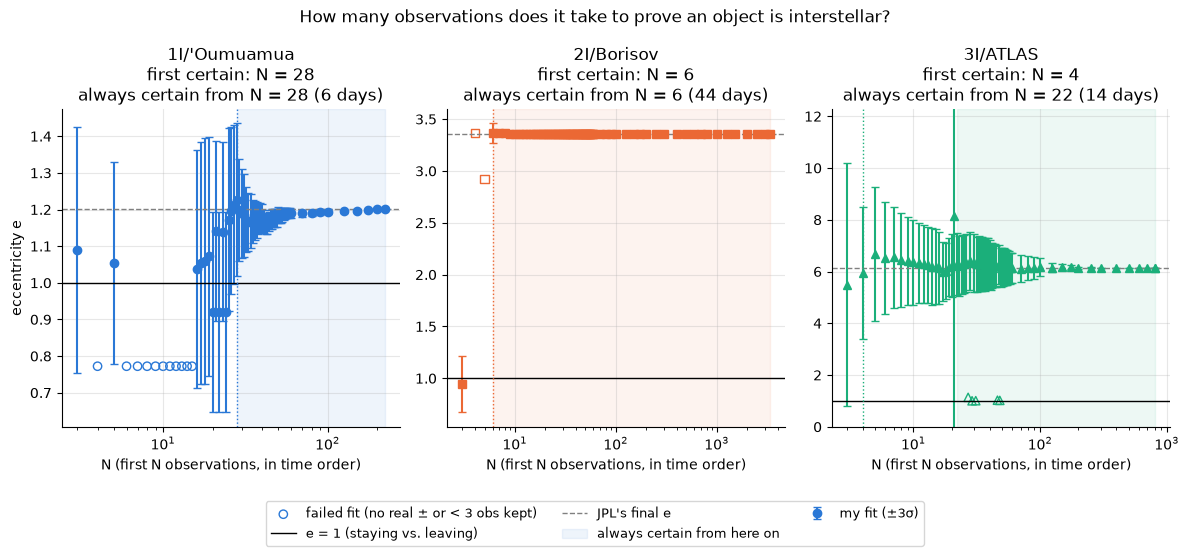

In [20]:
#This cell will create the actual "plot 2", for each ISO
STYLE = { #dict for the style of the different markers for each ISO
    "1I": ("#2a78d6", "o", "1I/'Oumuamua"),
    "2I": ("#eb6834", "s", "2I/Borisov"),
    "3I": ("#1baf7a", "^", "3I/ATLAS"),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 5.5)) #creates the actual plotting area

for ax, (obj, (color, marker, name)) in zip(axes, STYLE.items()): #puts each "panel" into the correct order
    part = first_n[first_n["object"] == obj] #keeps the current object's rows
    good = part["trust"] #true/false marking for each ISO point
    ax.errorbar(part["N"][good], part["e"][good], yerr=3 * part["sigma"][good], fmt=marker, color=color, capsize=3, label="my fit (±3σ)") #draws the "trusted" fits, with error bars
    ax.scatter(part["N"][~good], part["e"][~good], marker=marker, facecolors="none", edgecolors=color, label="failed fit (no real ± or < 3 obs kept)") #draws the "untrusted" fits
    ax.axhline(1, color="black", linewidth=1, label="e = 1 (staying vs. leaving)") #black line at e = 1
    ax.axhline(JPL_E[obj], color="gray", linestyle="--", linewidth=1, label="JPL's final e") #dashed gray line at JPL's e value for each object
    trusted = part[good]
    first = trusted.loc[trusted["certain"], "N"].min()
    last_unsure = trusted.loc[~trusted["certain"], "N"].max()
    stays = trusted.loc[trusted["N"] > last_unsure, "N"].min()
    stays_days = trusted.loc[trusted["N"] == stays, "days"].iloc[0]
    ax.axvline(first, color=color, linestyle=":", linewidth=1) #dotted vertical line at the N value with a "certain" e
    ax.axvspan(stays, part["N"].max(), color=color, alpha=0.08, label="always certain from here on")
    ax.set_title(f"{name}\nfirst certain: N = {first}\nalways certain from N = {stays} ({stays_days} days)") #panel title
    low, high = ax.get_ylim()
    ax.set_ylim(max(low, 0), min(high, 2 * JPL_E[obj]))
    ax.set_xscale("log") #makes the x-scale logarithmic
    ax.set_xlabel("N (first N observations, in time order)") #labels the x-axis
    ax.grid(alpha=0.3) #faint gridlines
    ax.spines[["top", "right"]].set_visible(False) #removes the top and right border lines, like a scatter plot

axes[0].set_ylabel("eccentricity e") #y-axis label, only on the first panel
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=9)
fig.suptitle("How many observations does it take to prove an object is interstellar?") #title (all panels)
fig.tight_layout(rect=[0, 0.11, 1, 1]) #optimizes spacing
fig.savefig("../figures/first_n_v2.png", dpi=200) #saves the figure, as first_n_v1.png
plt.show()